# Deteksi Spam Email/SMS Menggunakan Machine Learning
### Tugas Praktikum Kecerdasan Buatan — Bidang: Machine Learning
### Studi Kasus: Deteksi Spam pada Layanan Akademik dan TI Kampus

Notebook ini mendemonstrasikan penerapan **Machine Learning (Supervised Learning)** untuk
mengklasifikasikan pesan (email/SMS) ke dalam dua kelas: **spam** dan **ham (bukan spam)**.

Dataset yang digunakan adalah **SMS Spam Collection Dataset** (dataset publik yang umum
digunakan untuk riset dan pembelajaran deteksi spam), terdiri dari 5.572 pesan berlabel.
Struktur permasalahan (klasifikasi teks pendek menjadi spam/bukan spam) merepresentasikan
kasus nyata deteksi spam pada layanan email/notifikasi kampus.

**Algoritma yang digunakan:**
1. Multinomial Naive Bayes
2. Logistic Regression (sebagai model pembanding)

**Alur kerja notebook:**
1. Memuat dataset
2. Text preprocessing
3. Ekstraksi fitur TF-IDF
4. Pelatihan model
5. Evaluasi model (akurasi, precision, recall, F1-score, confusion matrix)
6. Pengujian pada contoh pesan baru


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

pd.set_option('display.max_colwidth', 80)


## 2. Memuat Dataset

Dataset `dataset_spam_sms.csv` berisi dua kolom: `label` (ham/spam) dan `text` (isi pesan).
File ini berada pada folder yang sama dengan notebook ini.


In [2]:
df = pd.read_csv("dataset_spam_sms.csv")
print("Jumlah data:", df.shape[0])
print("\nDistribusi label:")
print(df["label"].value_counts())
df.head(10)


Jumlah data: 5572

Distribusi label:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e bu..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"
5,spam,FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like ...
6,ham,Even my brother is not like to speak with me. They treat me like aids patent.
7,ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has b...
8,spam,WINNER!! As a valued network customer you have been selected to receivea å£9...
9,spam,Had your mobile 11 months or more? U R entitled to Update to the latest colo...


## 3. Text Preprocessing

Sebelum diekstraksi menjadi fitur numerik, teks pesan dibersihkan melalui beberapa langkah:
- Mengubah menjadi huruf kecil (case folding)
- Menghapus URL
- Menghapus angka dan simbol/tanda baca
- Merapikan spasi berlebih


In [3]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(preprocess_text)
df[["text", "clean_text"]].head(10)


,text,clean_text
0,"Go until jurong point, crazy.. Available only in bugis n great world la e bu...",go until jurong point crazy available only in bugis n great world la e buffe...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA ...,free entry in a wkly comp to win fa cup final tkts st may text fa to to rece...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives around here though",nah i don t think he goes to usf he lives around here though
5,FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like ...,freemsg hey there darling it s been week s now and no word back i d like som...
6,Even my brother is not like to speak with me. They treat me like aids patent.,even my brother is not like to speak with me they treat me like aids patent
7,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has b...,as per your request melle melle oru minnaminunginte nurungu vettam has been ...
8,WINNER!! As a valued network customer you have been selected to receivea å£9...,winner as a valued network customer you have been selected to receivea prize...
9,Had your mobile 11 months or more? U R entitled to Update to the latest colo...,had your mobile months or more u r entitled to update to the latest colour m...


## 4. Pembagian Data dan Ekstraksi Fitur TF-IDF

Data dibagi menjadi data latih (80%) dan data uji (20%) dengan stratifikasi berdasarkan label
agar proporsi kelas spam/ham tetap terjaga pada kedua subset. Representasi teks diubah menjadi
vektor numerik menggunakan TF-IDF (Term Frequency-Inverse Document Frequency).


In [4]:
X = df["clean_text"]
y = df["label"].map({"ham": 0, "spam": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(max_features=3000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Ukuran data latih :", X_train_tfidf.shape)
print("Ukuran data uji    :", X_test_tfidf.shape)


Ukuran data latih : (4457, 3000)
Ukuran data uji    : (1115, 3000)


## 5. Pelatihan Model

In [5]:
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_tfidf, y_train)

print("Model Naive Bayes dan Logistic Regression selesai dilatih.")


Model Naive Bayes dan Logistic Regression selesai dilatih.


## 6. Evaluasi Model

Model dievaluasi menggunakan data uji yang tidak dilihat selama pelatihan, dengan metrik:
akurasi, precision, recall, dan F1-score.


In [6]:
results = {}
for nama, model in [("Naive Bayes", model_nb), ("Logistic Regression", model_lr)]:
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[nama] = [acc, prec, rec, f1]
    print(f"===== {nama} =====")
    print(f"Akurasi   : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print()

hasil_df = pd.DataFrame(results, index=["Akurasi", "Precision", "Recall", "F1-Score"]).T
hasil_df


===== Naive Bayes =====
Akurasi   : 0.9731
Precision : 0.9837
Recall    : 0.8121
F1-Score  : 0.8897

===== Logistic Regression =====
Akurasi   : 0.9677
Precision : 1.0000
Recall    : 0.7584
F1-Score  : 0.8626



,Akurasi,Precision,Recall,F1-Score
Naive Bayes,0.973094,0.98374,0.812081,0.889706
Logistic Regression,0.967713,1.00000,0.758389,0.862595


### Confusion Matrix — Multinomial Naive Bayes

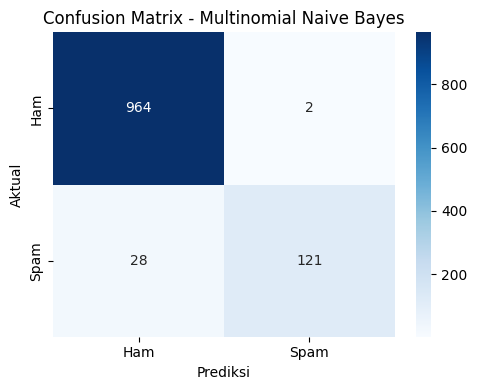

In [7]:
y_pred_nb = model_nb.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.tight_layout()
plt.savefig("confusion_matrix_nb.png", dpi=120)
plt.show()


In [8]:
print(classification_report(y_test, y_pred_nb, target_names=["Ham", "Spam"]))


              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.98      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115



## 7. Pengujian pada Contoh Pesan Baru

Model diuji dengan beberapa contoh pesan baru yang merepresentasikan konteks kampus
(pengumuman akademik) dan pesan mencurigakan (indikasi spam/phishing).


In [9]:
contoh_pesan = [
    "Congratulations! You have WON a free prize, click this link now to claim!",
    "Reminder: Your final exam schedule has been published on the academic portal.",
    "URGENT: Your account will be suspended, verify your password immediately at this link.",
    "The lecture for tomorrow is moved to room 301 at 9 AM.",
    "You have been selected for a cash reward of $5000, reply now to claim your prize."
]

contoh_bersih = [preprocess_text(t) for t in contoh_pesan]
contoh_tfidf = vectorizer.transform(contoh_bersih)
hasil_prediksi = model_nb.predict(contoh_tfidf)
hasil_proba = model_nb.predict_proba(contoh_tfidf)

for teks, label, proba in zip(contoh_pesan, hasil_prediksi, hasil_proba):
    kelas = "SPAM" if label == 1 else "HAM"
    print(f"[{kelas:4s}] (prob. spam={proba[1]:.3f})  {teks}")


[SPAM] (prob. spam=0.969)  Congratulations! You have WON a free prize, click this link now to claim!
[HAM ] (prob. spam=0.334)  Reminder: Your final exam schedule has been published on the academic portal.
[SPAM] (prob. spam=0.790)  URGENT: Your account will be suspended, verify your password immediately at this link.
[HAM ] (prob. spam=0.037)  The lecture for tomorrow is moved to room 301 at 9 AM.
[SPAM] (prob. spam=0.986)  You have been selected for a cash reward of $5000, reply now to claim your prize.


## 8. Kesimpulan Demonstrasi

Berdasarkan hasil pelatihan dan pengujian pada dataset SMS Spam Collection (5.572 pesan berlabel),
model **Multinomial Naive Bayes** dan **Logistic Regression** berhasil mengklasifikasikan pesan
spam dan ham dengan tingkat akurasi tinggi (lihat tabel hasil pada Bagian 6). Model juga berhasil
mengenali pola pesan baru yang belum pernah dilihat sebelumnya, termasuk pola umum phishing
("klik link", "verifikasi akun", "hadiah/reward") dan pesan akademik yang sah.

Hasil ini mendukung gagasan bahwa pendekatan Machine Learning dapat diterapkan secara efektif
untuk membangun sistem penyaring spam pada layanan email/notifikasi kampus, sebagaimana dibahas
pada laporan tugas praktikum yang menyertai notebook ini.

**Catatan:** Dataset yang digunakan berbahasa Inggris (dataset publik standar untuk riset spam).
Untuk implementasi nyata pada layanan kampus berbahasa Indonesia, disarankan mengumpulkan dan
melabeli dataset email/SMS berbahasa Indonesia agar model lebih representatif terhadap konteks
lokal.
